Trying different type of models for LST estimation

## General paths, libraries and functions

In [ ]:
!pip install seaborn
!pip install statsmodels
!pip install rasterstats

In [ ]:
import os
import numpy as np
import rasterio
from rasterio import mask
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import PolynomialFeatures
from rasterstats import zonal_stats


In [ ]:
# variables - Best results (pearson correlation with LST) for window size
lst_clipped_path = '../../datos-notebooks/0.LST/LST_clipped_celsius.tif' #values out of city boundary are nan

ndwi_1_path = '../../datos-notebooks/1.land-cover/moving-windows/ndwi/Class_1_window61.tif'
ndvi_1_path = '../../datos-notebooks/1.land-cover/moving-windows/ndvi/Class_1_window25.tif'
ndvi_0p5_path = '../../datos-notebooks/1.land-cover/moving-windows/ndvi/Class_0p5_window5.tif'
veg_vol_path = '../../datos-notebooks/2.objects-height/moving-windows/tree-volume/trees_window13.tif'
built_vol_path = '../../datos-notebooks/2.objects-height/moving-windows/building-volume/buildings_window13.tif'
built_area_path = '../../datos-notebooks/2.objects-height/moving-windows/building-area/building_area_window11.tif'
building_height_path = '../../datos-notebooks/2.objects-height/moving-windows/building-height/building_height_window21.tif'
mean_elev_path = '../../datos-notebooks/3.topography/moving_windows/elev_mean/elev_mean_win111.tif'
mean_slope_path = '../../datos-notebooks/3.topography/moving_windows/slope_mean/slope_mean_win19.tif'
northness_path = '../../datos-notebooks/3.topography/moving_windows/northness/northness_win201.tif'

census_areas_path = '../../datos-notebooks/sezioni-di-censimento-anno-2011.geojson'

output_dir = '../../datos-notebooks/4.LST-prediction/'
os.makedirs(output_dir, exist_ok=True)

In [ ]:
def stepwise_selection_aic(X, y, initial_list=None, min_delta=5, verbose=True):
    """
    Forward-backward stepwise selection based on AIC.
    """
    if initial_list is None:
        included = []
    else:
        included = list(initial_list)

    # Fit initial model (if any)
    if included:
        model = sm.OLS(y, sm.add_constant(X[included])).fit()
        current_aic = model.aic
    else:
        current_aic = np.inf

    while True:
        changed = False

        # ---------- Forward step ----------
        excluded = list(set(X.columns) - set(included))
        best_candidate = None
        best_aic = current_aic

        for col in excluded:
            model = sm.OLS(y, sm.add_constant(X[included + [col]])).fit()
            if model.aic < best_aic:
                best_aic = model.aic
                best_candidate = col

        if best_candidate is not None and (current_aic - best_aic) > min_delta:
            included.append(best_candidate)
            current_aic = best_aic
            changed = True
            if verbose:
                print(f"Add {best_candidate:30} AIC = {best_aic:.2f}")

        # ---------- Backward step ----------
        if included:
            worst_candidate = None
            best_aic_back = current_aic

            for col in included:
                temp = included.copy()
                temp.remove(col)
                if temp:
                    model = sm.OLS(y, sm.add_constant(X[temp])).fit()
                    if model.aic < best_aic_back:
                        best_aic_back = model.aic
                        worst_candidate = col

            if worst_candidate is not None and (current_aic - best_aic_back) > min_delta:
                included.remove(worst_candidate)
                current_aic = best_aic_back
                changed = True
                if verbose:
                    print(f"Drop {worst_candidate:30} AIC = {best_aic_back:.2f}")

        if not changed:
            break

    return included


## Dataset preparation

### mask rasters to city boundary

In [ ]:
with rasterio.open(lst_clipped_path) as src:
    lst = src.read(1)

lst_mask = np.isnan(lst)

# mask values out of city boundary
ndwi_1 = np.where(lst_mask, np.nan, rasterio.open(ndwi_1_path).read(1).astype("float32"))
ndvi_1 = np.where(lst_mask, np.nan, rasterio.open(ndvi_1_path).read(1).astype("float32"))
ndvi_0p5 = np.where(lst_mask, np.nan, rasterio.open(ndvi_0p5_path).read(1).astype("float32"))
veg_vol = np.where(lst_mask, np.nan, rasterio.open(veg_vol_path).read(1).astype("float32"))
built_vol = np.where(lst_mask, np.nan, rasterio.open(built_vol_path).read(1).astype("float32"))
built_area = np.where(lst_mask, np.nan, rasterio.open(built_area_path).read(1).astype("float32"))
built_height = np.where(lst_mask, np.nan, rasterio.open(building_height_path).read(1).astype("float32"))
mean_elev = np.where(lst_mask, np.nan, rasterio.open(mean_elev_path).read(1).astype("float32"))
mean_slope = np.where(lst_mask, np.nan, rasterio.open(mean_slope_path).read(1).astype("float32"))
northness = np.where(lst_mask, np.nan, rasterio.open(northness_path).read(1).astype("float32"))

rasters_masked = {
    "Water": ndwi_1,
    "Dense vegetation presence": ndvi_1,
    "Sparse vegetation presence": ndvi_0p5,
    "Vegetation volume": veg_vol,
    "Built volume": built_vol,
    "Built area": built_area,
    "Building height": built_height,
    "Elevation": mean_elev,
    "Slope": mean_slope,
    "Northness": northness
}


In [ ]:
#plot masked rasters 

fig, axes = plt.subplots(3, 3, figsize=(15, 15))

for ax, (name, data) in zip(axes.flat, rasters_masked.items()):

    img = ax.imshow(data, cmap='viridis')
    ax.set_title(name)
    ax.axis('off')
    fig.colorbar(img, ax=ax, fraction=0.046, pad=0.04)


plt.tight_layout()
plt.show()

In [ ]:
# Plot histograms of masked rasters
fig, axes = plt.subplots(2, 5, figsize=(16, 8))
axes = axes.flatten()  # Flatten to 1D for easy indexing

for i, (name, arr) in enumerate(rasters_masked.items()):
    # Plot histogram using already-masked arrays
    axes[i].hist(arr[~np.isnan(arr)], bins=50)
    axes[i].set_title(name)
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Frequency")

# Hide unused subplots (if less than 8 rasters)
for j in range(i + 1, 8):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

### standarize variables - mean:0, std:1

In [ ]:
output_dir = '../../datos-notebooks/4.LST-prediction/standarized_variables'
os.makedirs(output_dir, exist_ok=True)

In [ ]:
# Z-score standardization for regression predictors

def standardize_array(arr, profile, out_path):
    mean = np.nanmean(arr)
    std = np.nanstd(arr)
    z = (arr - mean) / std

    profile.update(dtype='float32')

    with rasterio.open(out_path, 'w', **profile) as dst:
        dst.write(z.astype('float32'), 1)

In [ ]:
# Apply standarization
with rasterio.open(lst_clipped_path) as src:
    profile = src.profile.copy()
    
standardize_array(ndwi_1, profile, os.path.join(output_dir, 'NDWI_1_z.tif'))
standardize_array(ndvi_1, profile, os.path.join(output_dir, 'NDVI_1_z.tif'))
standardize_array(ndvi_0p5, profile, os.path.join(output_dir, 'NDVI_0p5_z.tif'))
standardize_array(veg_vol, profile, os.path.join(output_dir, 'VEG_VOL_z.tif'))
standardize_array(built_vol, profile, os.path.join(output_dir, 'BUILT_VOL_z.tif'))
standardize_array(built_area, profile, os.path.join(output_dir, 'BUILT_AREA_z.tif'))
standardize_array(built_height, profile, os.path.join(output_dir, 'BUILDING_HEIGHT_z.tif'))
standardize_array(mean_elev, profile, os.path.join(output_dir, 'ELEV_z.tif'))
standardize_array(mean_slope, profile, os.path.join(output_dir, 'SLOPE_z.tif'))
standardize_array(northness, profile, os.path.join(output_dir, 'NORTH_z.tif'))

In [ ]:
std_rasters_paths = {
    "Water": os.path.join(output_dir, "NDWI_1_z.tif"),
    "Dense veg. presence": os.path.join(output_dir, "NDVI_1_z.tif"),
    "Sparse veg. presence": os.path.join(output_dir, "NDVI_0p5_z.tif"),
    "Vegetation Volume": os.path.join(output_dir, "VEG_VOL_z.tif"),
    #"Built Volume": os.path.join(output_dir, "BUILT_VOL_z.tif"),  # Excluded to prevent duplication of information
    "Built Area": os.path.join(output_dir, "BUILT_AREA_z.tif"),
    "Built Height": os.path.join(output_dir, "BUILDING_HEIGHT_z.tif"),
    "Elevation": os.path.join(output_dir, "ELEV_z.tif"),
    "Slope": os.path.join(output_dir, "SLOPE_z.tif"),
    "Northness": os.path.join(output_dir, "NORTH_z.tif")
}

In [ ]:
#plot cropped and standardized rasters

fig, axes = plt.subplots(2, 5, figsize=(15, 15))

for ax, (name, path) in zip(axes.flat, std_rasters_paths.items()):
    with rasterio.open(path) as src:
        data = src.read(1).astype(float)

    img = ax.imshow(data, cmap='viridis')
    ax.set_title(name)
    ax.axis('off')
    fig.colorbar(img, ax=ax, fraction=0.046, pad=0.04)


plt.tight_layout()
plt.show()

In [ ]:

fig, axes = plt.subplots(2, 5, figsize=(16, 8))
axes = axes.flatten()  # Flatten to 1D for easy indexing

for i, (name, path) in enumerate(std_rasters_paths.items()):
    with rasterio.open(path) as src:
        arr = src.read(1).astype("float32")
        nodata = src.nodata

    # Plot histogram
    axes[i].hist(arr[~np.isnan(arr)], bins=50)
    axes[i].set_title(name)
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Frequency")
    axes[i].axvline(0, linestyle='--')

plt.tight_layout()
plt.show()

### stratified sampling of LST

In [ ]:
rasters = {"LST": lst_clipped_path} # create dictionary with LST raster (not standardized)
rasters.update(std_rasters_paths) # add standardized rasters to the dictionary
#rasters.pop("Variable name", None) # to delete one variable if needed


In [ ]:
rasters

In [ ]:
# Create bins
n_bins = 10

# Read and flatten
data_arrays = {}
for name, path in rasters.items():
    with rasterio.open(path) as src:
        arr = src.read(1)
        data_arrays[name] = arr.flatten()

df = pd.DataFrame(data_arrays)

df = df.dropna() # Drop rows with NaN

df['LST_bin'] = pd.qcut(df['LST'], n_bins, labels=False) # Create LST bins for stratification 

In [ ]:
# Stratified sampling: 10% of each bin

sample_fraction = 0.1
df_sampled = df.groupby('LST_bin', group_keys=False).apply(
    lambda x: x.sample(frac=sample_fraction, random_state=42)
)

# Drop bin column
df_sampled = df_sampled.drop(columns=['LST_bin']).reset_index(drop=True)

print(df_sampled.head())


In [ ]:
# Show min, max and count of LST values in each bin

df_sampled['LST_bin'] = pd.qcut(df_sampled['LST'], n_bins, labels=False) # Recreate bins for the sampled dataset

for b in range(n_bins):
    values_in_bin = df_sampled[df_sampled['LST_bin'] == b]['LST']
    print(f"Bin {b}: min = {values_in_bin.min():.2f}, max = {values_in_bin.max():.2f}, count = {len(values_in_bin)}")

df_sampled = df_sampled.drop(columns=['LST_bin'])

### Descriptive statistics

In [ ]:
# Split features and target
X = df_sampled.drop(columns=['LST'])
y = df_sampled['LST']

In [ ]:
# Compute correlation matrix (only features)
corr_matrix = X.corr()

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Feature Correlation Matrix")
plt.show()


In [ ]:
# Vegetation plot: area vs volume
plt.figure()
plt.scatter(
    df_sampled["Dense veg. presence"],
    df_sampled["Vegetation Volume"],
    s=1, alpha=0.5
)
plt.xlabel("Vegetation presence (z)")
plt.ylabel("Vegetation volume (z)")
plt.title("Vegetation: Area vs Volume")
plt.show()

# Built plot: area vs height
plt.figure()
plt.scatter(
    df_sampled["Built Area"],
    df_sampled["Built Height"],
    s=1, alpha=0.5
)
plt.xlabel("Built area (z)")
plt.ylabel("Built Height (z)")
plt.title("Built: Area vs Height")
plt.show()


In [ ]:
# Plot correlations: Variables vs LST

n_vars = len(X)

fig, axes = plt.subplots(2, 5, figsize=(10, 6))
axes = axes.flatten() 

for i, v in enumerate(X.columns):
    axes[i].scatter(X[v], y, s=1, alpha=0.3)
    axes[i].set_xlabel(v)
    axes[i].set_ylabel("LST")
    axes[i].set_title(f"LST vs {v}")

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for i, v in enumerate(df.columns):
    axes[i].boxplot(df[v], vert=False)
    axes[i].set_title(v)

for ax in axes[len(df.columns):]:
    ax.axis('off')

plt.tight_layout()
plt.show()


### PCA

In [ ]:
df_sampled

In [ ]:
y = df_sampled["LST"].values
X = df_sampled.drop(columns=["LST"])

In [ ]:
X

In [ ]:
predictor_names = X.columns.tolist()

# Standardization
scaler = StandardScaler()
X_std = scaler.fit_transform(X)

# PCA
pca = PCA()
X_pca = pca.fit_transform(X_std)


In [ ]:
plt.figure(figsize=(6,4))
plt.plot(np.arange(1, len(pca.explained_variance_ratio_)+1),
         np.cumsum(pca.explained_variance_ratio_), marker="o")
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.ylim(0,1)
plt.title("Cumulative variance")
plt.grid(True)
plt.show()


In [ ]:
# Loadings
loadings = pd.DataFrame(
    pca.components_.T,       # each column is a PC
    columns=[f"PC{i+1}" for i in range(X.shape[1])],
    index=predictor_names     # original variable names
)

plt.figure(figsize=(12,6))
sns.heatmap(loadings, annot=True, cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("PC Loadings")
plt.show()


## Different models

### linear regression using PCs

In [ ]:
X = X_pca[:, :8]  # Choose how many PCs to use
y = df_sampled["LST"].values


# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Add intercept for statsmodels
X_train_sm = sm.add_constant(X_train)
X_test_sm = sm.add_constant(X_test)


ols_model = sm.OLS(y_train, X_train_sm).fit() # Fit OLS model

print(ols_model.summary())


In [ ]:
# Error metrics on test set
y_pred = ols_model.predict(X_test_sm) # Predict on test set

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"\nTest set R²: {r2:.3f}")
print(f"Test set RMSE: {rmse:.3f}")

### linear regression using PCs + stepwise

In [ ]:
X = X_pca[:, :8]  # Choose how many PCs to use
y = df_sampled["LST"].values

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Convert PCs to DataFrame with numbers as column names
X_df = pd.DataFrame(X_train, columns=[f"PC{i+1}" for i in range(X_train.shape[1])])
y_train_vals = y_train  # already an array

# Stepwise selection using function
selected_pcs = stepwise_selection_aic(
    X=X_df,
    y=y_train_vals,
    initial_list=None,   
    min_delta=100,       # change if needed
    verbose=True        
)

print("\nSelected PCs (train):", selected_pcs)




In [ ]:
pc_names = [f"PC{i+1}" for i in range(X_train.shape[1])]

# Fit final model on train with selected PCs
final_idx = [pc_names.index(v) for v in selected_pcs]
X_train_final = X_train_sm[:, [0] + [i+1 for i in final_idx]]
X_test_final  = X_test_sm[:, [0] + [i+1 for i in final_idx]]

final_model = sm.OLS(y_train, X_train_final).fit()
print("\n--- Train summary ---")
print(final_model.summary())

In [ ]:
# Error metrics with test set

y_pred = final_model.predict(X_test_final) # Predict on test set


r2_test = r2_score(y_test, y_pred)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"\nTest set R²: {r2_test:.3f}")
print(f"Test set RMSE: {rmse_test:.3f}")


### linear regression using original variables

In [ ]:
X = df_sampled.drop(columns=['LST'])
y = df_sampled['LST']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Add intercept (constant) for OLS
X_train_sm = sm.add_constant(X_train)
X_test_sm  = sm.add_constant(X_test)

ols_model = sm.OLS(y_train, X_train_sm).fit() # Fit OLS model on training set

print(ols_model.summary())



In [ ]:
# Error metrics
y_pred = ols_model.predict(X_test_sm) # Predict on test set

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"\nTest set R²: {r2:.3f}")
print(f"Test set RMSE: {rmse:.3f}")


### Linear regression using original variables + Stepwise

In [ ]:
X = df_sampled.drop(columns=['LST'])
y = df_sampled['LST']

# Stepwise selection 
selected_features = stepwise_selection_aic(
    X=X,
    y=y,
    initial_list=None,   
    min_delta=100,       
    verbose=True         
)


In [ ]:
X = df_sampled[selected_features]
y = df_sampled["LST"].values

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Add intercept (constant) for OLS
X_train_const = sm.add_constant(X_train)
X_test_const = sm.add_constant(X_test)

ols_model = sm.OLS(y_train, X_train_const).fit()
print(ols_model.summary())



In [ ]:
# Error metrics
y_pred = ols_model.predict(X_test_const)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"\nTest set R²: {r2:.3f}")
print(f"Test set RMSE: {rmse:.3f}")

### Linear regression using polynomial (grade 2) terms in original variables + stepwise

In [ ]:
X = df_sampled.drop(columns=['LST'])
y = df_sampled['LST']


In [ ]:
# Create polynomial features (degree 2)
poly = PolynomialFeatures(degree=2, interaction_only=False, include_bias=False)
X_poly = poly.fit_transform(X)

# obtain feature names
poly_features = poly.get_feature_names_out(X.columns)
X_poly_df = pd.DataFrame(X_poly, columns=poly_features)

X_train, X_test, y_train, y_test = train_test_split(
    X_poly_df, y, test_size=0.2, random_state=42
)


In [ ]:
# Stepwise selection on polynomial features (train)
selected_poly_features = stepwise_selection_aic(
    X=X_train,
    y=y_train,
    initial_list=None,  
    min_delta=50,      
    verbose=True        
)




In [ ]:
# Ajust OLS with selected variables
X_train_sel = sm.add_constant(X_train[selected_poly_features])
X_test_sel = sm.add_constant(X_test[selected_poly_features])

ols_poly_model = sm.OLS(y_train, X_train_sel).fit()
print(ols_poly_model.summary())



In [ ]:
# Error metrics
y_pred = ols_poly_model.predict(X_test_sel)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"\nTest set R²: {r2:.3f}")
print(f"Test set RMSE: {rmse:.3f}")

### Random Forest

In [ ]:
df_sampled

In [ ]:
X = df_sampled.drop(columns=['LST'])
y = df_sampled['LST']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Random Forest Regressor
rf_model = RandomForestRegressor(
    n_estimators=500,       # number of trees
    max_depth=None,         # no max depth
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)


In [ ]:
# Error metrics
y_pred = rf_model.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R²: {r2:.3f}")
print(f"RMSE: {rmse:.3f}")




In [ ]:
# Variable importance
importances = rf_model.feature_importances_

# Create dataframe for sorting
importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": importances
})

# Sort by importance (descending)
importance_df = importance_df.sort_values(by="importance", ascending=False)

# Print ordered results
for _, row in importance_df.iterrows():
    print(f"{row['feature']}: {row['importance']:.3f}")

In [ ]:
plt.figure()
plt.scatter(y_test, y_pred, s=1)  
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], color="black")
plt.xlabel("Observed LST")
plt.ylabel("Predicted LST")
plt.title(f"Observed vs Predicted (R²={r2:.2f}, RMSE={rmse:.2f})")
plt.show()


In [ ]:
# Residuals plot
residuals = y_test - y_pred

plt.figure()
plt.scatter(y_pred, residuals, s=1)
plt.axhline(0, color='black')
plt.xlabel("Predicted LST")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted")
plt.show()


## Applying RF model in all the city

In [ ]:
print(X.columns.tolist())


In [ ]:
output_dir = '../../datos-notebooks/4.LST-prediction/'

# Predictor order (MUST match training)
predictor_order = [
    "Water",
    "Dense veg. presence",
    "Sparse veg. presence",
    "Vegetation Volume",
    "Built Area",
    "Built Height",
    "Elevation",
    "Slope",
    "Northness"
]


# Read rasters using 'rasters' dict
arrays = []
meta = None

for name in predictor_order:
    path = rasters[name]   # get path from existing dict
    with rasterio.open(path) as src:
        arr = src.read(1)
        arrays.append(arr)
        if meta is None:
            meta = src.meta.copy()

stack = np.stack(arrays, axis=-1)  # (rows, cols, n_features)


# Mask nodata pixels
nodata_mask = np.any(np.isnan(stack), axis=-1)


# Reshape for model prediction
nrows, ncols, nbands = stack.shape
X_map = stack.reshape(-1, nbands)

valid = ~nodata_mask.ravel()
X_valid = X_map[valid]

# Predict LST
y_map = np.full(X_map.shape[0], np.nan)   # allocate output
y_map[valid] = rf_model.predict(X_valid) # calls the trained model

# Back to raster shape
lst_pred = y_map.reshape(nrows, ncols)

# Save raster
meta.update(dtype="float32", count=1, nodata=np.nan)

out_path = os.path.join(output_dir, "LST_predicted_RF.tif")

with rasterio.open(out_path, "w", **meta) as dst:
    dst.write(lst_pred.astype("float32"), 1)
    

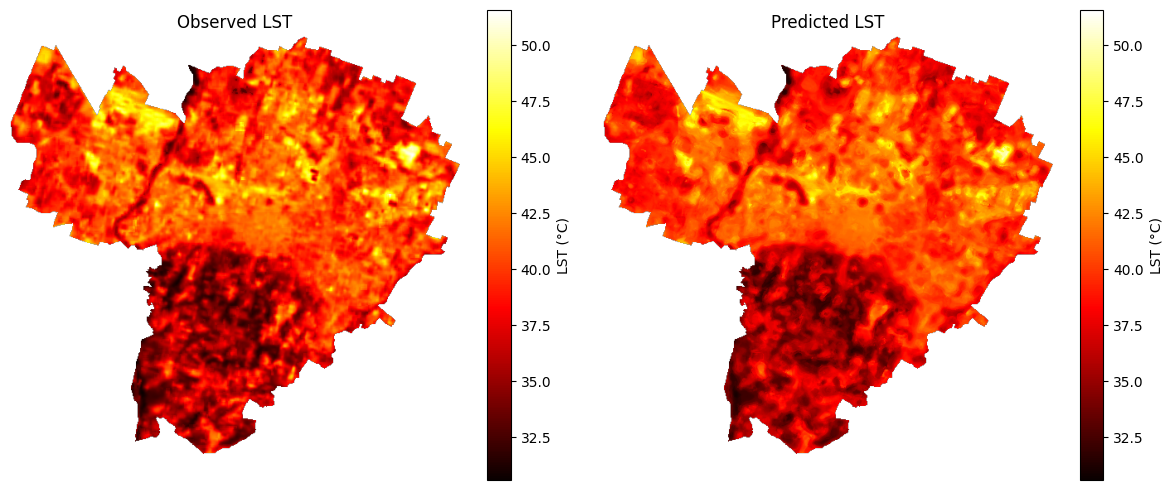

In [38]:
# Plot observed vs predicted LST

lst_predicted_path = '../../datos-notebooks/4.LST-prediction/LST_predicted_RF.tif'

with rasterio.open(lst_clipped_path) as src:
    lst_observed = src.read(1)

with rasterio.open(lst_predicted_path) as src:
    lst_pred = src.read(1)
    
vmin = np.nanmin(lst_observed)
vmax = np.nanmax(lst_observed)

# Plot 
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(lst_observed, vmin=vmin, vmax=vmax, cmap="hot")  # thermal colormap
plt.colorbar(label="LST (°C)")
plt.title("Observed LST")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(lst_pred, vmin=vmin, vmax=vmax, cmap="hot")  # same colormap
plt.colorbar(label="LST (°C)")
plt.title("Predicted LST")
plt.axis("off")

plt.tight_layout()
plt.show()


## Extracting results for census areas

In [24]:
with rasterio.open(lst_predicted_path) as src:
    lst_pred = src.read(1)
    lst_transform = src.transform
    lst_crs = src.crs
    
census_areas = gpd.read_file(census_areas_path)
census_areas = census_areas.to_crs(lst_crs)

In [ ]:
# Extract statistics
stats = zonal_stats(
    census_areas,
    lst_predicted_path,
    stats=["min", "max", "mean"],
    nodata=None  # o poné el nodata real si tu raster lo tiene
)

# Create a new  nuevo GeoDataFrame with statistics + geometry
census_stats = gpd.GeoDataFrame({
    "min_LST":  [s["min"]  for s in stats],
    "max_LST":  [s["max"]  for s in stats],
    "mean_LST": [s["mean"] for s in stats]
},
geometry=census_areas.geometry,
crs=census_areas.crs)


In [25]:
census_stats.head()

,min_LST,max_LST,mean_LST,geometry
0,41.730209,42.374184,41.954887,"MULTIPOLYGON (((682979.045 4930444.93, 682928...."
1,39.392017,43.331860,41.001575,"MULTIPOLYGON (((682163.461 4930480.473, 682248..."
2,39.600735,42.472809,40.822533,"MULTIPOLYGON (((680647.21 4930374.717, 680641...."
3,40.817394,42.346436,41.720978,"MULTIPOLYGON (((683901.956 4930473.832, 683997..."
4,42.011944,42.654755,42.323230,"MULTIPOLYGON (((685579.299 4930425.746, 685591..."


In [ ]:
census_stats.to_file(os.path.join(output_dir,"LST_census_areas.gpkg"), driver="GPKG")

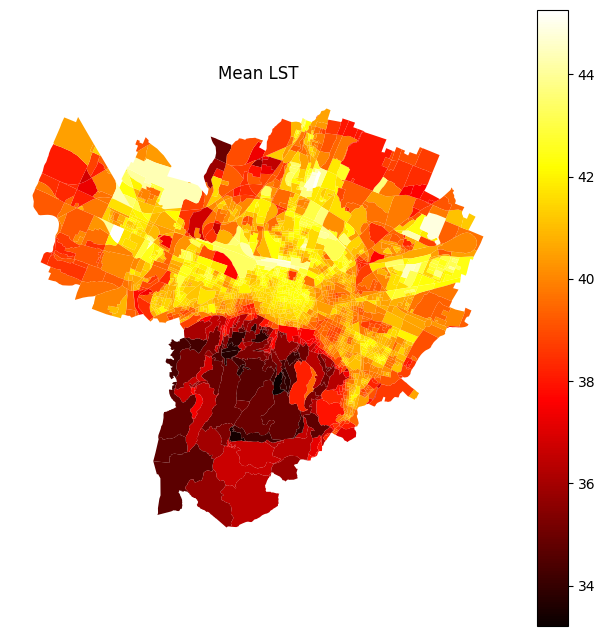

In [40]:
gdf = gpd.read_file(os.path.join(output_dir, "LST_census_areas.gpkg"))

fig, ax = plt.subplots(figsize=(8,8))
gdf.plot(column="mean_LST", cmap="hot", legend=True, ax=ax, linewidth=0, edgecolor="none")
ax.set_title("Mean LST")
ax.set_axis_off()
plt.show()


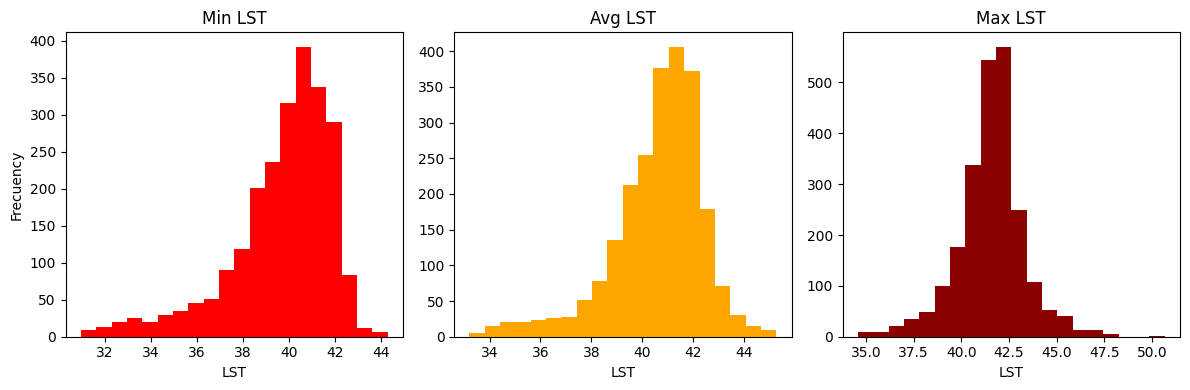

In [42]:
plt.figure(figsize=(12,4))

# Min
plt.subplot(1,3,1)
plt.hist(census_stats["min_LST"].dropna(), bins=20, color="red")
plt.title("Min LST")
plt.xlabel("LST")
plt.ylabel("Frecuency")

# Mean
plt.subplot(1,3,2)
plt.hist(census_stats["mean_LST"].dropna(), bins=20, color="orange")
plt.title("Avg LST")
plt.xlabel("LST")

# Max
plt.subplot(1,3,3)
plt.hist(census_stats["max_LST"].dropna(), bins=20, color="darkred")
plt.title("Max LST")
plt.xlabel("LST")

plt.tight_layout()
plt.show()
